In [6]:
library(DESeq2)
library(TxDb.Hsapiens.UCSC.hg38.knownGene)
library(ChIPseeker)
library(org.Hs.eg.db)
library(clusterProfiler)

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following objects are masked from ‘package:lubridate’:

    second, second<-


The

ERROR: Error in value[[3L]](cond): Package ‘matrixStats’ version 1.5.0 cannot be unloaded:
 Error in unloadNamespace(package) : namespace ‘matrixStats’ is imported by ‘MatrixGenerics’, ‘DESeq2’ so cannot be unloaded



In [ ]:
library(tidyverse)

In [ ]:
library(survminer)
library(ggplot2)
library(survival)

In [ ]:
library(GenomicRanges)

In [ ]:
library(ggpubr)
library(ggthemes)
library(ggrastr)
library(ggplot2)

In [ ]:
library(RColorBrewer)

In [7]:
library(edgeR)

Loading required package: limma


Attaching package: ‘limma’


The following object is masked from ‘package:BiocGenerics’:

    plotMA




In [8]:
phe <- read.table(file = "phe_plusTF_footprint.txt",header=T)

In [28]:
rownames(phe) <- phe$name

In [29]:
phe  %>% filter(footprint == 'C2')  %>% select(footprint) %>% rownames() -> a

In [30]:
phe  %>% filter(footprint == 'C3')  %>% select(footprint)  %>% rownames() -> b

In [50]:
#Top20Peaks <- readRDS(file="Top20VarPeaks.Rdata")
data_atac <- readRDS(file = "ATAC_mean.RDS")
peak_region<- readRDS(file="peak_region.Rdata")

In [51]:
dim(data_atac)

[1] 121300     38

In [199]:
DoGO <- function(gene_id){
    #gene_id = data$geneId
    data_go <- enrichGO(gene = 
                             gene_id,
                             OrgDb = org.Hs.eg.db,
                             ont = "ALL",
                             pAdjustMethod = "BH",
                             qvalueCutoff = 0.05,
                             pvalueCutoff = 0.05,
                             readable = TRUE
                        )
    return(data_go)
}

In [193]:
DoKEGG <- function(gene_id){
   # gene_id = data$geneId
    data_kegg <- enrichKEGG(gene        = gene_id,
                         organism     = 'hsa',
                          qvalueCutoff = 1,
                         pvalueCutoff = 1)
    for(i in 1:nrow(data_kegg@result)){
        data_kegg@result$geneID[i]  %>% str_split('/')  %>% .[[1]] ->a
        a2 <- bitr(a, fromType="ENTREZID", toType="SYMBOL", OrgDb="org.Hs.eg.db")
        paste0(a2$SYMBOL ,collapse = '/') -> a3
        data_kegg@result$geneID[i] <- a3
}
    return(data_kegg)
}

In [31]:
deseq <- function(data_for_compare,coldata_for_compare){
 
    dds_compare <- DESeqDataSetFromMatrix(data_for_compare, coldata_for_compare, design= ~ footprint)
    dds_compare <- DESeq(dds_compare)
    res = results(dds_compare)
    res = res[order(res$pvalue),]
    diff_res <- subset(res, padj < 0.05 & abs(log2FoldChange) > log2(1.5))
    diff = as.data.frame(diff_res)
    allres = as.data.frame(res)

    diff_name=rownames(diff)
    all_name=rownames(allres)
    compare <- mcols(res)$description[2] %>% strsplit(split = ":") %>% .[[1]] %>% .[2]
    compare2 <- compare %>% strsplit(split=" footprint ") %>% .[[1]] %>% .[2] %>% strsplit(split=" vs ") %>% .[[1]]
    
    diff$category = NA
    diff[diff$log2FoldChange>0,]$category = compare2[1]
    diff[diff$log2FoldChange<0,]$category = compare2[2]
    allres <- allres[!is.na(allres$padj),]
    allres$category = NA
    allres[allres$log2FoldChange>0,]$category = compare2[1]
    allres[allres$log2FoldChange<0,]$category = compare2[2]
    
    diff %>% rownames() %>% peak_region[.,] %>%  cbind(.,diff) -> diff
    allres %>% rownames() %>% peak_region[.,] %>%  cbind(.,allres) -> allres
    return(list(all=allres,diff=diff,dds=dds_compare))
}

In [61]:
plot_valcano <- function(mydata,gcolor){
    
    mydata$logP <- -log10(mydata$padj)
    mydata %>% mutate(group = case_when(padj<=0.05&log2FoldChange>log2(1.5) ~ "C3", 
                                                  padj<=0.05&log2FoldChange<(-log2(1.5)) ~ "C2",
                                                  padj>0.05|abs(log2FoldChange)<log2(1.5) ~"NoSig" )) -> mydata
    mytable <- table(mydata$group)
    p_high <- ggscatter(mydata, x = "log2FoldChange", y = "logP", color = "group", 
            palette = c("#ca0020","#0571b0","#BBBBBB"), size = 1, ## blue, grey,red 
            xlab = "log2FoldChange", ylab = "-log10(Adjust P-value)")+xlim(-3,3)+
    ggthemes::theme_base()+geom_hline(yintercept = -log10(0.05), linetype="dashed")+ylim(0,20)+
    geom_vline(xintercept = c(-log2(1.5),log2(1.5)), linetype="dashed")+
    annotate("text", x = 2, y = 15, label = mytable[2])+ 
    annotate("text", x = -2, y = 15, label = mytable[1])
    p <- ggrastr::rasterize(p_high,dpi=400)
    return(p)
}


In [33]:
data_atac <- mutate_all(data_atac, function(x) as.integer(x))

In [34]:
peak_region_gr <- makeGRangesFromDataFrame(peak_region)

In [60]:
dim(data_atac)

[1] 121300     38

In [36]:
colnames(data_atac)  %>% phe[.,] -> phe

### deseq

In [ ]:
rlt_all <- deseq(data_atac,phe)

In [38]:
rlt_all$diff %>% filter(category=="C2") %>% .[,c(1,2,3)] %>% makeGRangesFromDataFrame() -> rlt_all_C2
rlt_all$diff %>% filter(category=="C3") %>% .[,c(1,2,3)] %>% makeGRangesFromDataFrame() -> rlt_all_C3

### valcano plot

In [64]:
library(ggrastr)

In [65]:
options(repr.plot.height=6,repr.plot.width=6)
p_valcano <- rasterize(plot_valcano(rlt_all$all),dpi=300)
#p_valcano_top20 <- plot_valcano(rlt_top20$all)

Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”


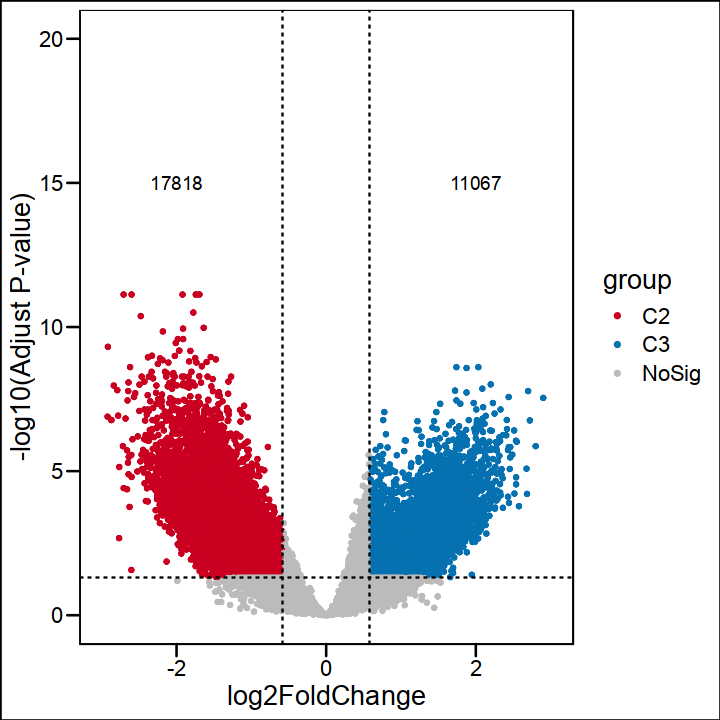

In [66]:
p_valcano

In [67]:
ggsave(filename = "Deseq2.vocalno.pdf",plot = p_valcano,width = 6,height = 6)

Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”


### do genomic annotation

In [94]:
peak_region_gr <- makeGRangesFromDataFrame(peak_region)

In [95]:
rlt_all_C2_C3_list <- list(C2 = rlt_all_C2,C3 = rlt_all_C3,all=peak_region_gr)

In [96]:
peakAnnoList_all <- lapply(rlt_all_C2_C3_list, annotatePeak, TxDb=TxDb.Hsapiens.UCSC.hg38.knownGene,
                       tssRegion=c(-3000, 3000), verbose=FALSE,annoDb = "org.Hs.eg.db")

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns



In [97]:
options(repr.plot.height=4,repr.plot.width=8)
p_genomic_anno <- plotAnnoBar(peakAnnoList_all)

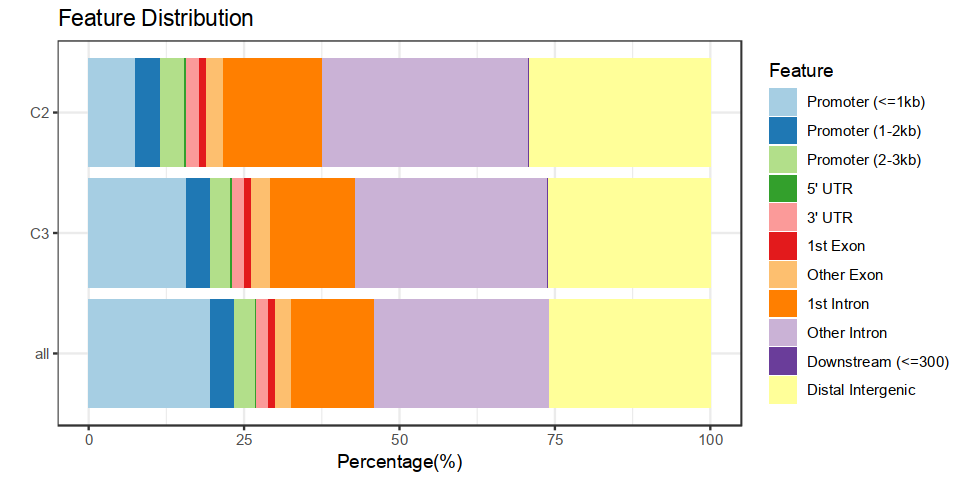

In [98]:
p_genomic_anno

In [99]:
ggsave(plot = p_genomic_anno,filename = "ATAC_genomic_anno.pdf",height = 4,width = 8)

### combine deseq2 and genomic annotation

In [68]:
peakAnnoList_all$all@anno %>% as.data.frame() -> all_peak_anno

In [69]:
rlt_all$all  %>% rownames() %>% all_peak_anno[.,c('annotation','geneId','transcriptId','distanceToTSS','ENSEMBL','SYMBOL','GENENAME')] %>% 
        cbind(rlt_all$all,.) -> all_deseq2_peak_anno

In [70]:
rlt_all$diff  %>% rownames() %>% all_peak_anno[.,c('annotation','geneId','transcriptId','distanceToTSS','ENSEMBL','SYMBOL','GENENAME')] %>% 
        cbind(rlt_all$diff,.) -> Diff_deseq2_peak_anno

In [71]:
saveRDS(object = all_deseq2_peak_anno,file = "all_deseq2_peak_anno.Rdata")

In [72]:
saveRDS(object = Diff_deseq2_peak_anno,file = "Diff_deseq2_peak_anno.Rdata")

In [73]:
openxlsx::write.xlsx(list(All=all_deseq2_peak_anno,Diff=Diff_deseq2_peak_anno),rowNames = TRUE, 
                     file = "all_deseq2_peak_anno.xlsx")

In [74]:
write.table(x = Diff_deseq2_peak_anno,quote = F,sep = "\t",row.names = F,
                     file = "all_deseq2_peak_anno.txt")

### check glycogenes

In [55]:
Aminogenes <- c("GPT", "GPT2", "GLUD1", "GOT1", "GOT2", "PANK1", "ALDH2", "CPS1", "ASS1", "ASL", 
           "OTC", "PAH", "BCAT1", "BCAT2", "BCKDHA", "ALDH6A1", "ALDH7A1", 
           "HGD", "GLDC", "SHMT1")


In [56]:
fattygenes <- c("ACSL4", "ACSL1", "ACSL3", "ACSL5", "ACSL6", "ACOX1", "ACOX2", "ACAA2", "ACADM", "ACADL", 
           "ACADVL", "ACAD8", "ACAD9", "ACAD10", "ACAD11", "ACADS", "CPT1A", "CPT1B", "CPT2", 
           "SLC25A20", "EHHADH", "HADH", "HADHA", "HADHB", "HSD17B4")

In [57]:
glycogenes <- c('HK1','HK2','HK3', 'GCK','GPI','PFKM','PFKL','PFKFB2','PFKFB3','PFKFB4','PFKP','ALDOA', 
           'ALDOB','ALDOC','TPI1','GAPDH','PGK1','PGAM1','PGAM2','PGAM4',
           'ENO1', 'ENO2', 'ENO3','PKM','PKLR','LDHA','PDK1')

In [58]:
tcacogenes <- c('PDC','CS','ACO2','IDH1','IDH2','OGDH','SUCLA2','SDHD','FH','MDH1','MDH2')

In [59]:
mas = c('MDH1','MDH2','GOT1','GOT2','SLC1A3','SLC25A12','SLC25A13','SLC25A11')

In [60]:
all_deseq2_peak_anno  %>% filter(SYMBOL %in% glycogenes)  %>% 
    filter(padj<0.05&abs(log2FoldChange)>1)  %>%  
    select(SYMBOL,log2FoldChange,padj,category)  %>%  arrange(SYMBOL)  %>%  filter(!duplicated(SYMBOL))

,SYMBOL,log2FoldChange,padj,category
,<chr>,<dbl>,<dbl>,<chr>
ATACpeak_119015,ALDOB,1.248596,1.226455e-02,C3
ATACpeak_13962,HK1,-2.170517,1.476440e-05,C2
ATACpeak_54848,HK2,1.378609,1.211418e-02,C3
ATACpeak_9484,PFKFB2,-1.451380,2.648463e-04,C2
ATACpeak_12193,PFKFB3,-1.873923,1.134799e-08,C2
ATACpeak_12039,PFKP,-1.655569,2.565038e-05,C2


#### TCA

In [61]:
all_deseq2_peak_anno  %>% filter(SYMBOL %in% tcacogenes)  %>% 
    filter(padj<0.05&abs(log2FoldChange)>1)  %>%  
    select(SYMBOL,log2FoldChange,padj,category)  %>%  arrange(SYMBOL)  %>%  filter(!duplicated(SYMBOL))

,SYMBOL,log2FoldChange,padj,category
,<chr>,<dbl>,<dbl>,<chr>
ATACpeak_67461,ACO2,1.912027,3.926925e-05,C3
ATACpeak_11657,FH,-1.178754,2.729584e-05,C2
ATACpeak_103565,OGDH,1.172767,5.552802e-03,C3
ATACpeak_8475,PDC,-1.253085,7.836687e-05,C2


#### Amino

In [62]:
all_deseq2_peak_anno  %>% filter(SYMBOL %in% Aminogenes)  %>% 
    filter(padj<0.05&abs(log2FoldChange)>1)  %>%  
    select(SYMBOL,log2FoldChange,padj,category)  %>%  arrange(SYMBOL)  %>%  filter(!duplicated(SYMBOL))

,SYMBOL,log2FoldChange,padj,category
,<chr>,<dbl>,<dbl>,<chr>
ATACpeak_34149,ALDH6A1,-2.067334,1.002688e-06,C2
ATACpeak_120746,ASS1,1.381815,1.097423e-02,C3
ATACpeak_24101,BCAT1,1.197056,7.252920e-04,C3
ATACpeak_60642,CPS1,1.304689,9.552587e-04,C3
ATACpeak_116116,GLDC,-1.822528,3.043276e-03,C2
ATACpeak_14579,GLUD1,1.166502,2.988750e-02,C3
ATACpeak_39993,GPT2,1.361023,2.125440e-04,C3
ATACpeak_27306,PAH,2.901441,2.886580e-08,C3


#### fattyacid

In [63]:
all_deseq2_peak_anno  %>% dplyr::filter(SYMBOL %in% fattygenes)  %>% 
    dplyr::filter(padj<0.05&abs(log2FoldChange)>1)  %>%  
    select(SYMBOL,log2FoldChange,padj,category)  %>%  arrange(SYMBOL)  %>%  dplyr::filter(!duplicated(SYMBOL))

,SYMBOL,log2FoldChange,padj,category
,<chr>,<dbl>,<dbl>,<chr>
ATACpeak_47360,ACAA2,-1.379292,3.670892e-05,C2
ATACpeak_27832,ACAD10,1.115236,9.861913e-03,C3
ATACpeak_74152,ACAD11,-1.125251,5.039866e-03,C2
ATACpeak_4245,ACADM,-1.353788,2.639522e-03,C2
ATACpeak_71131,ACOX2,1.095150,6.974384e-03,C3
ATACpeak_61353,ACSL3,-1.891203,4.366902e-05,C2
ATACpeak_15561,ACSL5,-1.453967,2.069042e-02,C2
ATACpeak_89808,ACSL6,1.274600,3.794393e-03,C3
ATACpeak_19510,CPT1A,-1.465130,4.039984e-03,C2


### write differential peaks out

In [64]:
library(dplyr)

In [122]:
rlt_all$diff  %>% filter(category=="C2") %>% select(c("chr","start","end")) -> C2_peaks
rlt_all$diff  %>% filter(category=="C3") %>% select(c("chr","start","end")) -> C3_peaks

In [75]:
rlt_all$diff   %>% select(chr,start,end,padj,log2FoldChange,category)  -> sig_bedfile
write.table(x = sig_bedfile,file = "ATAC.sigdiff.peaks.bed",sep='\t',quote = F,row.names = F)

In [123]:
C2_peaks %>% mutate(center = round((end+start)/2),center2 =round((end+start)/2)+1 ) %>% select("chr","center","center2") ->  C2_peaks_center
C3_peaks %>% mutate(center = round((end+start)/2),center2 =round((end+start)/2)+1) %>% select("chr","center","center2")  ->  C3_peaks_center

In [124]:
colnames(C2_peaks_center) <- c("chr","start","end")
colnames(C3_peaks_center) <- c("chr","start","end")

In [125]:
write.table(x =C2_peaks,file = "C2_peaks.FC1.5.bed",quote = F,sep = "\t",row.names = F )
write.table(x =C3_peaks,file = "C3_peaks.FC1.5.bed",quote = F,sep = "\t",row.names = F )

In [69]:
write.table(x =C2_peaks_center,file = "C2_peaks_center.bed",quote = F,sep = "\t",row.names = F )
write.table(x =C3_peaks_center,file = "C3_peaks_center.bed",quote = F,sep = "\t",row.names = F )

### GO annotation

In [11]:
get_plot <- function(C2_go,C3_go){
    C2_go %>% as.data.frame()  -> C2_temp
    C3_go %>% as.data.frame() -> C3_temp
    C2_temp  %>% select(Description,GeneRatio,p.adjust,Count) %>% 
    mutate(group = "C2") -> C2_temp2
    C3_temp  %>% select(Description,GeneRatio,p.adjust,Count)  %>% 
        mutate(Description=Description,group = "C3") -> C3_temp2
    if(nrow(C2_temp2)>25){
        C2_temp2 = C2_temp2[1:25,]
    }else if(nrow(C2_temp2)>0){
        C2_temp2 = C2_temp2[1:nrow(C2_temp2),]
    }else{
        C2_temp2 = C2_temp
    }
        
    if(nrow(C3_temp2)>25){
        C3_temp2 = C3_temp2[1:25,]
    }else if(nrow(C3_temp2)>0){
        C3_temp2 = C3_temp2[1:nrow(C3_temp2),]
    }else{
        C3_temp2 = C3_temp
    }
    
    rbind(C2_temp2,C3_temp2) -> C2_C3_comb
    
    
   # C2_C3_comb %>% mutate(GeneRatio2 = sapply(GeneRatio,function(x) eval(parse(text = x))))  -> C2_C3_comb
  #  C2_C3_comb  %>% mutate(GeneRatio2 = ifelse(group=="C2",-GeneRatio2,GeneRatio2)) -> C2_C3_comb
  #  C2_C3_comb$Description  <- factor(C2_C3_comb$Description,levels = unique(C2_C3_comb  %>% arrange((Count)) %>% .[,1]))
  #  ceiling(max(abs(C2_C3_comb$GeneRatio2))  * 100) / 100 -> xrange
    
    C2_C3_comb  %>% mutate(GeneRatio2 = ifelse(group=="C2",'C2','C3')) -> C2_C3_comb
    C2_C3_comb$Description  <- factor(C2_C3_comb$Description,levels = unique(C2_C3_comb  %>% arrange((Count)) %>% .[,1]))

    p <- ggplot(data = C2_C3_comb) + geom_point(aes(x=GeneRatio2,y = Description,size=Count,color=p.adjust)) + 
        theme(panel.background = element_rect(fill="NA"),
              panel.grid.major.y = element_line(color='gray',linetype='dashed'),
              axis.text = element_text(color = 'black'),
             panel.border = element_rect(fill=NA,color='black'),) + geom_vline(xintercept = 0) +
           # xlim(-xrange,xrange)+
            ylab('')+xlab('') + theme(axis.text.y = element_text(size=11)) +
             scale_colour_gradientn(colors = colorRampPalette(c("red", "blue"))(80))
          #  ggtitle(label =mytype )
    return(p)
}

In [141]:
Diff_deseq2_peak_anno %>% filter(category =="C2" ) %>% select(geneId) -> C2_genesID
Diff_deseq2_peak_anno %>% filter(category =="C3" ) %>% select(geneId) -> C3_genesID

In [174]:
RNA <- readRDS('RNA.res.Rds')

In [181]:
RNA  %>% filter(category=='C2' & padj <0.05 & log2FoldChange< -log2(1.5))  %>% rownames() -> C2genes
RNA  %>% filter(category=='C3' & padj <0.05 & log2FoldChange> log2(1.5))  %>% rownames() -> C3genes

In [ ]:
C2geneid = bitr(c(C2genes), fromType="ALIAS", toType="ENTREZID", OrgDb="org.Hs.eg.db")
C3geneid = bitr(c(C3genes), fromType="ALIAS", toType="ENTREZID", OrgDb="org.Hs.eg.db")

In [190]:
C2_genesID$geneId  %>% intersect(C2geneid$ENTREZID)  -> C2_gene_isct
C3_genesID$geneId  %>% intersect(C3geneid$ENTREZID)  -> C3_gene_isct

In [191]:
C2_go <- DoGO(C2_genesID)
C3_go <- DoGO(C3_genesID)

In [ ]:
C2_KEGG <- DoKEGG(C2_gene_isct)
C3_KEGG <- DoKEGG(C3_gene_isct)

In [200]:
C2_go <- DoGO(C2_gene_isct)
C3_go <- DoGO(C3_gene_isct)

In [74]:
C2_KEGG  %>% as.data.frame()  %>% rownames() -> C2_keggterms
C3_KEGG  %>% as.data.frame()  %>% rownames() -> C3_keggterms

In [75]:
C2_keggterms  %>% setdiff(C3_keggterms) -> C2_unique_keggterms
C3_keggterms  %>% setdiff(C2_keggterms) -> C3_unique_keggterms

In [76]:
C2_go  %>% as.data.frame()  %>% rownames() -> C2_goterms
C3_go  %>% as.data.frame()  %>% rownames() -> C3_goterms
C2_goterms  %>% setdiff(C3_goterms) -> C2_unique_goterms
C3_goterms  %>% setdiff(C2_goterms) -> C3_unique_goterms

In [77]:
openxlsx::write.xlsx(x = list(C2 = as.data.frame(C2_KEGG),C3 = as.data.frame(C3_KEGG),
                             C2unique =as.data.frame(C2_KEGG)[C2_unique_keggterms,],
                             C3unique =as.data.frame(C3_KEGG)[C3_unique_keggterms,]),
                     file="ATAC.KEGG.FC1.5.xlsx")

In [78]:
openxlsx::write.xlsx(x = list(C2 = as.data.frame(C2_go),C3 = as.data.frame(C3_go),
                             C2unique =as.data.frame(C2_go)[C2_unique_goterms,],
                             C3unique =as.data.frame(C3_go)[C3_unique_goterms,]),
                     file="ATAC.GO.FC1.5.xlsx")

In [12]:
p <- get_plot(C2_go,C3_go)

In [13]:
p2 <- get_plot(C2_KEGG,C3_KEGG)

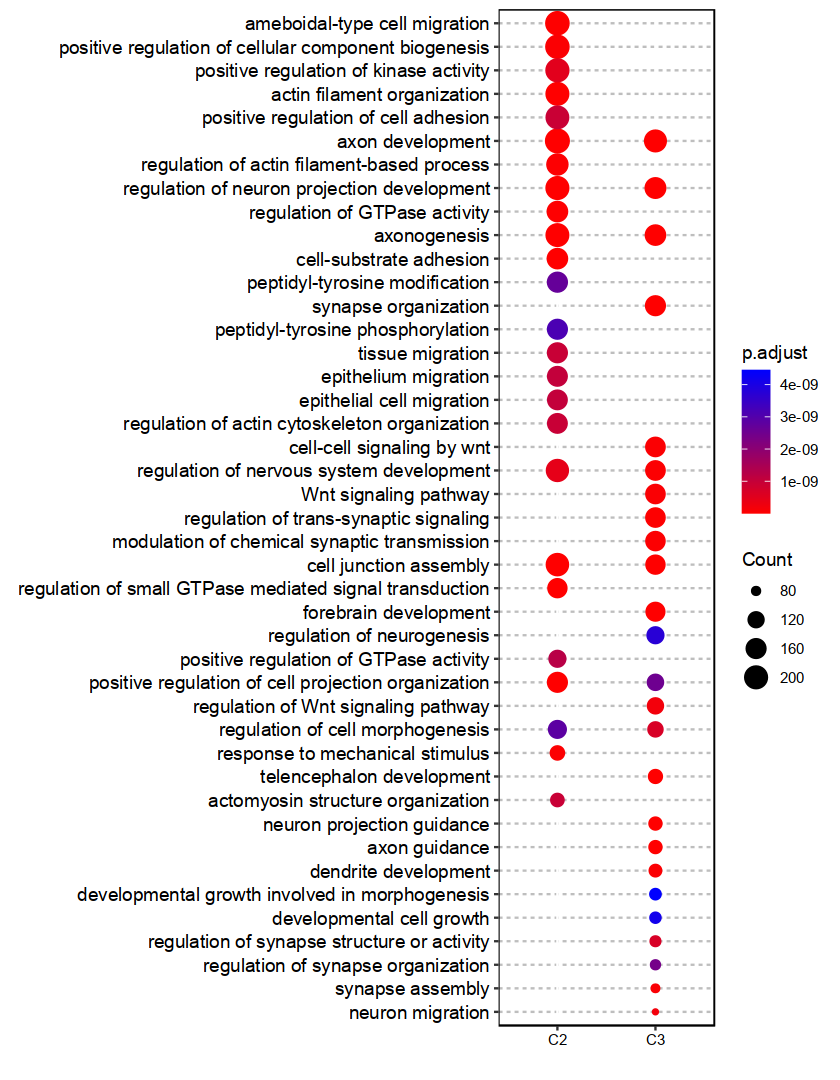

In [20]:
options(repr.plot.height=9,repr.plot.width=7)
p

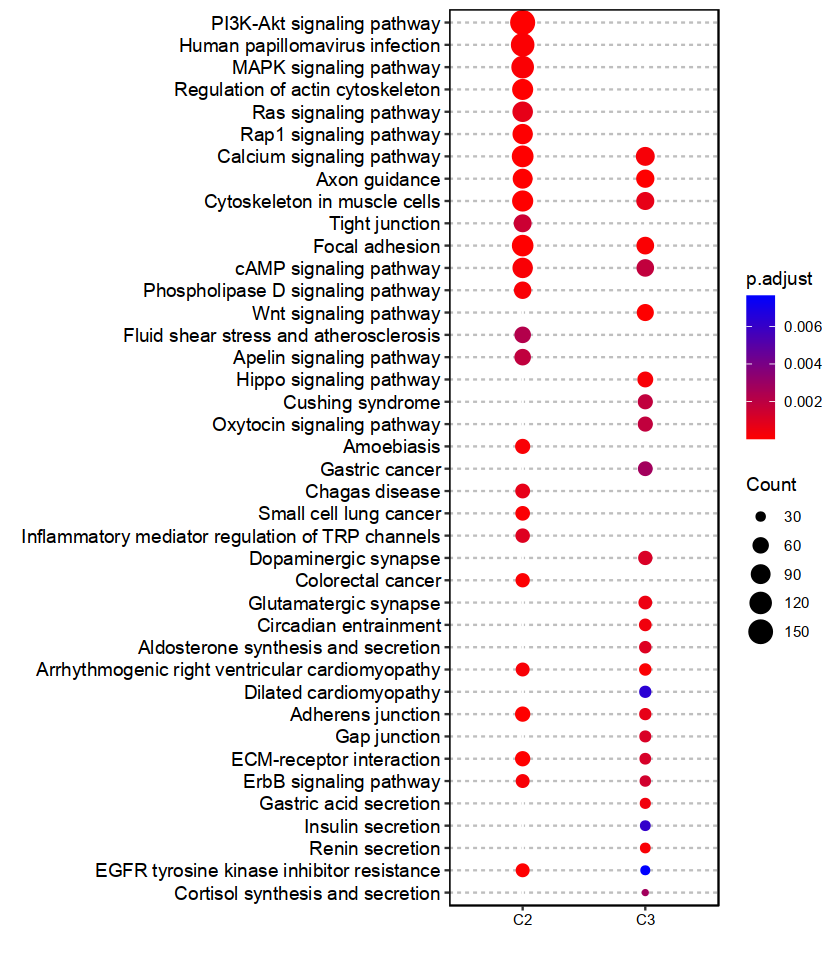

In [21]:
options(repr.plot.height=8,repr.plot.width=7)
p2

In [22]:
ggsave(filename = "C2C3_Diffpeaks_GO.FC1.5.pdf", plot = p, width = 7, height = 9)

In [24]:
ggsave(filename = "C2C3_Diffpeaks_KEGG.FC1.5.pdf", plot = p2, width = 6, height = 8)

In [84]:
openxlsx::write.xlsx(list(C2GO=as.data.frame(C2_go),C3GO=as.data.frame(C3_go)),rowNames = TRUE, 
                     file = "ATAC.GO.FC1.5.xlsx")

In [205]:
openxlsx::write.xlsx(list(C2GO=as.data.frame(C2_go),C3GO=as.data.frame(C3_go)),rowNames = TRUE, 
                     file = "ATAC.GO.isct_RNAseq.FC1.5.xlsx")

In [209]:
openxlsx::write.xlsx(list(C2GO=as.data.frame(C2_KEGG),C3GO=as.data.frame(C3_KEGG)),rowNames = TRUE, 
                     file = "ATAC.KEGG.isct_RNAseq.FC1.5.xlsx")

### GO simplify

In [201]:
library(simplifyEnrichment)

In [ ]:
active_mat_C2 = GO_similarity(C2_go %>% as.data.frame() %>% rownames(),ont="BP")
active_mat_C3 = GO_similarity(C3_go %>% as.data.frame() %>% rownames(),ont="BP")

In [ ]:
pdf(file ="GO_simplify_C2_isctRNAseq_heatmap.pdf" ,width = 9,height = 6)
df_act_C2 = simplifyGO(active_mat_C2)
dev.off()

In [ ]:
pdf(file ="GO_simplify_C3_isctRNAseq_heatmap.pdf" ,width = 9,height = 6)
df_act_C3 = simplifyGO(active_mat_C3)
dev.off()

In [89]:
save.image("Diff.temp.Rdata")

In [8]:
load('Diff.temp.Rdata')

In [20]:
Diff_deseq2_peak_anno %>% filter(str_detect(annotation,'Promoter'))  %>% filter(abs(distanceToTSS)<100) -> filtered

In [28]:
filtered  %>% filter(!str_detect(SYMBOL,'LOC')) %>% filter(!str_detect(SYMBOL,'LINC')) -> filter2

In [41]:
filter2  %>% filter(SYMBOL=='NAV3')

,chr,start,end,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,category,annotation,geneId,transcriptId,distanceToTSS,ENSEMBL,SYMBOL,GENENAME
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>
ATACpeak_26228,chr12,78035721,78036649,57.19420,1.4458685,0.2435266,5.937209,2.899143e-09,8.474890e-07,C3,Promoter (<=1kb),89795,ENST00000644176.1,0,ENSG00000067798,NAV3,neuron navigator 3
ATACpeak_26204,chr12,77324489,77325637,83.35367,0.5891953,0.1864791,3.159578,1.579976e-03,1.070856e-02,C3,Promoter (<=1kb),89795,ENST00000550042.2,0,ENSG00000067798,NAV3,neuron navigator 3


In [32]:
openxlsx::write.xlsx(filter2,file="filter2.fortfbs.xlsx")

In [49]:
Diff_deseq2_peak_anno  %>% filter(category=='C3')  %>% arrange(desc(log2FoldChange))  %>% select(chr,start,end)  %>% head(n=100) -> C3top100

In [51]:
write.table(C3top100,file = "C3_top100.bed",sep='\t',row.names = F)